# Tuning Exploration Parameters

## 📚 Learning Objectives

By completing this notebook, you will:
- Tune exploration parameters (epsilon, temperature, etc.)
- Understand parameter impact on performance
- Find optimal exploration settings
- Apply parameter tuning strategies

## 🔗 Prerequisites

- ✅ Understanding of exploration strategies
- ✅ Understanding of hyperparameter tuning
- ✅ Python, NumPy, Matplotlib knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 4**:
- Tuning exploration parameters

---

## Introduction

Tuning exploration parameters is crucial for balancing exploration and exploitation effectivel

## Lesson Brief

This lesson shows that exploration is not only about choosing a strategy, but also about tuning its parameters well.

Students will see how choices such as epsilon size or decay schedule affect learning outcomes.

Why this matters: an algorithm can fail not because the idea is wrong, but because its exploration settings are poor.

This lesson builds practical instinct for parameter tuning.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **ritvikmath - "Best Multi-Armed Bandit Strategy? (feat: UCB Method)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=FgmMK6RPU1c)

Why this pick:
- concrete parameter-sensitive examples.
- Helps students see how exploration settings change learning behavior over time.
- Good companion when interpreting tuning experiments rather than only running them.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nTuning Exploration Parameters")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nKey Exploration Parameters:")
# Show text or numbers in the cell output area under the code.
print("  - Epsilon (ε): Exploration rate for epsilon-greedy")
# Show text or numbers in the cell output area under the code.
print("  - Temperature (τ): For Boltzmann exploration")
# Show text or numbers in the cell output area under the code.
print("  - Confidence parameter (c): For UCB")
# Show text or numbers in the cell output area under the code.
print("  - Decay rate: For epsilon decay schedules")

# Show text or numbers in the cell output area under the code.
print("\nTuning Strategies:")
# Show text or numbers in the cell output area under the code.
print("  1. Grid search over parameter ranges")
# Show text or numbers in the cell output area under the code.
print("  2. Adaptive schedules (decay over time)")
# Show text or numbers in the cell output area under the code.
print("  3. Context-dependent parameters")
# Show text or numbers in the cell output area under the code.
print("  4. Performance-based tuning")

# Show text or numbers in the cell output area under the code.
print("\n✅ Parameter tuning concepts covered!")


✅ Libraries imported!

Tuning Exploration Parameters

Key Exploration Parameters:
  - Epsilon (ε): Exploration rate for epsilon-greedy
  - Temperature (τ): For Boltzmann exploration
  - Confidence parameter (c): For UCB
  - Decay rate: For epsilon decay schedules

Tuning Strategies:
  1. Grid search over parameter ranges
  2. Adaptive schedules (decay over time)
  3. Context-dependent parameters
  4. Performance-based tuning

✅ Parameter tuning concepts covered!


## 🌍 Worked Example — Tuning Epsilon in A/B Testing

**Industry context:**
- Product teams often keep the bandit setup fixed but tune exploration strength
- A weak epsilon can lock onto a bad option too early
- A very high epsilon can waste traffic on poor variants for too long

We run the same A/B test with several **epsilon values** so students can see how parameter tuning changes performance even when the strategy stays the same.

### Step Guide

**What this cell does:** Tunes ε **properly**: every ε value is run **50 times with different seeds**, and the comparison uses the *mean* total reward (± standard deviation) — because a single noisy run cannot rank exploration parameters.

**How to read it (weak Python OK):** `run_epsilon_greedy` is one simulation; the double loop repeats it 50× per ε. The table of means is the result; the "single-run trap" lines show why averaging was necessary.

**What to expect in the output:** A mean ± std table with the best ε computed from the means, a demonstration of how much single runs disagree, and a two-panel figure (average curves + mean totals with error bars).

**If you feel lost:** Compare the *spread* column with the *differences between rows* — when spread is as large as the differences, one run alone proves nothing.

Total reward per epsilon (50 runs of 2000 rounds each):
   ε    |  mean ± std   |  min … max across runs
  0.01 |   489.0 ± 120.3 |   292 …   704
  0.05 |   599.6 ±  76.2 |   314 …   697
   0.1 |   623.7 ±  50.1 |   475 …   691
   0.3 |   610.8 ±  35.7 |   508 …   673

Best epsilon by MEAN total reward: ε=0.1

The single-run trap: judging by one run alone, 27 of 50 runs
would have crowned a DIFFERENT epsilon than the 50-run average does.
That is why the earlier lessons' single-seed bandit plots can only illustrate
behaviour — ranking parameters requires averaging over many runs.


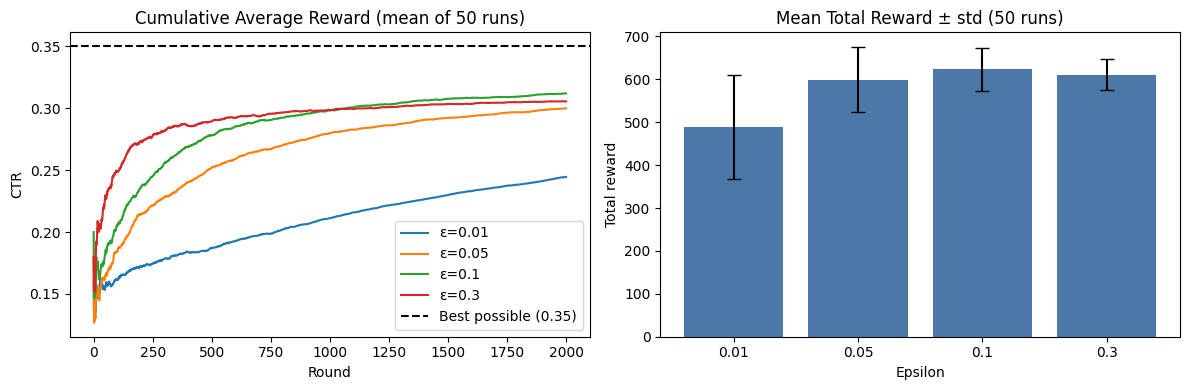

In [2]:
# Worked example: tune epsilon PROPERLY — many runs per value, conclusions from means.
# A single run per epsilon is a lottery ticket; averaging over seeds is what makes
# a tuning table trustworthy. We also SHOW the single-run trap explicitly below.

import numpy as np, matplotlib.pyplot as plt

# Hidden truth of the A/B test: 5 variants, variant 2 is best (35% CTR).
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]
N_ARMS = len(TRUE_RATES)
N_ROUNDS = 2000
EPSILONS = [0.01, 0.05, 0.10, 0.30]
N_RUNS = 50                      # independent simulations per epsilon value
BEST_RATE = max(TRUE_RATES)


def run_epsilon_greedy(eps, seed):
    """One full epsilon-greedy simulation; returns the per-round reward array."""
    rng = np.random.default_rng(seed)
    counts, totals = np.zeros(N_ARMS), np.zeros(N_ARMS)
    rewards = []
    for _ in range(N_ROUNDS):
        # Explore uniformly with probability eps, otherwise exploit the running means.
        if rng.random() < eps:
            arm = rng.integers(N_ARMS)
        else:
            arm = int(np.argmax(totals / (counts + 1e-9)))
        reward = 1 if rng.random() < TRUE_RATES[arm] else 0
        counts[arm] += 1
        totals[arm] += reward
        rewards.append(reward)
    return np.array(rewards)


# ── The experiment: N_RUNS independent simulations for every epsilon ─────────
results = {}
for eps in EPSILONS:
    # Different seed per run; the same 50 seeds are reused for every epsilon.
    run_matrix = np.stack([run_epsilon_greedy(eps, seed=1000 + k) for k in range(N_RUNS)])
    per_run_totals = run_matrix.sum(axis=1)
    results[eps] = {
        "mean_curve": run_matrix.cumsum(axis=1).mean(axis=0)
                       / np.arange(1, N_ROUNDS + 1),   # average cumulative CTR
        "totals": per_run_totals,                        # 50 total rewards
        "mean": per_run_totals.mean(),
        "std": per_run_totals.std(),
    }

# ── Report means, spread, and the best epsilon BY THE MEANS ──────────────────
print(f"Total reward per epsilon ({N_RUNS} runs of {N_ROUNDS} rounds each):")
print("   ε    |  mean ± std   |  min … max across runs")
for eps in EPSILONS:
    r = results[eps]
    print(f"  {eps:>4} |  {r['mean']:6.1f} ± {r['std']:5.1f} | {r['totals'].min():5.0f} … {r['totals'].max():5.0f}")

best_eps = max(results, key=lambda e: results[e]["mean"])
print(f"\nBest epsilon by MEAN total reward: ε={best_eps}")

# ── The single-run trap, demonstrated with this very data ────────────────────
# How often would looking at ONE run (same seed index for each ε) have picked
# a different winner than the 50-run average did?
single_run_winners = [max(EPSILONS, key=lambda e: results[e]["totals"][k]) for k in range(N_RUNS)]
disagree = sum(w != best_eps for w in single_run_winners)
print(f"\nThe single-run trap: judging by one run alone, {disagree} of {N_RUNS} runs")
print(f"would have crowned a DIFFERENT epsilon than the {N_RUNS}-run average does.")
print("That is why the earlier lessons' single-seed bandit plots can only illustrate")
print("behaviour — ranking parameters requires averaging over many runs.")

# ── Plots: averaged learning curves + mean totals with error bars ────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for eps in EPSILONS:
    plt.plot(results[eps]["mean_curve"], label=f"ε={eps}")
plt.axhline(BEST_RATE, color="k", linestyle="--", label=f"Best possible ({BEST_RATE})")
plt.title(f"Cumulative Average Reward (mean of {N_RUNS} runs)")
plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()

plt.subplot(1, 2, 2)
labels = [str(e) for e in EPSILONS]
means = [results[e]["mean"] for e in EPSILONS]
stds = [results[e]["std"] for e in EPSILONS]
plt.bar(labels, means, yerr=stds, capsize=5, color="#4C78A8")
plt.title(f"Mean Total Reward ± std ({N_RUNS} runs)")
plt.xlabel("Epsilon"); plt.ylabel("Total reward")
plt.tight_layout(); plt.show()


In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.
"""))


## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.


## 📝 Summary

You tuned the **exploration parameter ε** for ε-greedy the right way: 50 independent runs per ε value, comparison by mean total reward ± spread, and a computed best-ε — plus a direct demonstration of the *single-run trap*, where judging by one run frequently crowns the wrong parameter. The methodology is the real lesson: exploration parameters (ε here; τ for Boltzmann, from lesson 02; the bonus scale c for UCB, lesson 03) can only be ranked by averaging over many runs. Real applications: A/B traffic allocation, ad bidding, recommendation engines.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


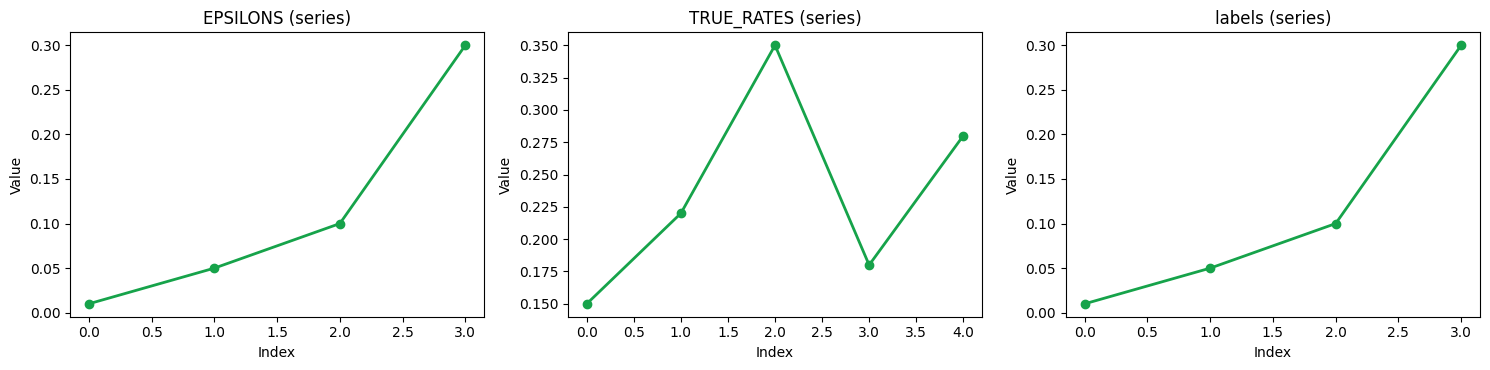

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Parameter tuning changes how aggressively or cautiously an agent explores, which can strongly affect speed and final performance.

**If students remember one idea:** A strategy is only half the story. Its parameter values determine how it behaves in the real run.

**Quick check before moving on:**
- Can you explain why a strong method can still perform poorly with weak parameter choices?
- Can you describe which signals you would inspect while tuning exploration?

**Bridge to the next step:** This closes Unit 4 and prepares students to apply RL ideas in larger, more realistic domains.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=4 | term=True | trunc=False


objc[19183]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fffc138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1104f89c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[19183]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fffc188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1104f8a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[19183]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fffbc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1104f8a68). T

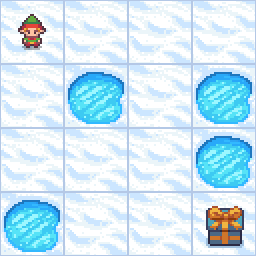

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
